# Simple model for MNIST Classification

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## The `MNIST` Dataset

Keras makes [**datasets**](https://www.tensorflow.org/api_docs/python/tf/keras/datasets) available to us:
- *tabular*: `boston_housing` (regression)
- *Images* : `mnist`, `fashion_mnist`, `cifar10`, `cifar100` (classification)
- *Texts*: `imbd`, `reuters` (classification/sentiment analysis)


We will **load the MNIST dataset**:

In [13]:
from tensorflow.keras import datasets

# Loading the MNIST Dataset...
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data(path="mnist.npz")

# The train set contains 60 000 images, each of them of size 28x28
# The test set contains 10 000 images, each of them of size 28x28
print(f"Image training dataset: {X_train.shape}, Labels for training dataset: {y_train.shape}")
print(f"Image test dataset:     {X_test.shape}, Labels for test dataset:     {y_test.shape}")

Image training dataset: (60000, 28, 28), Labels for training dataset: (60000,)
Image test dataset:     (10000, 28, 28), Labels for test dataset:     (10000,)


### 1.1 Exploring the dataset

Let's have look at some handwritten digits of this MNIST dataset.** ❓

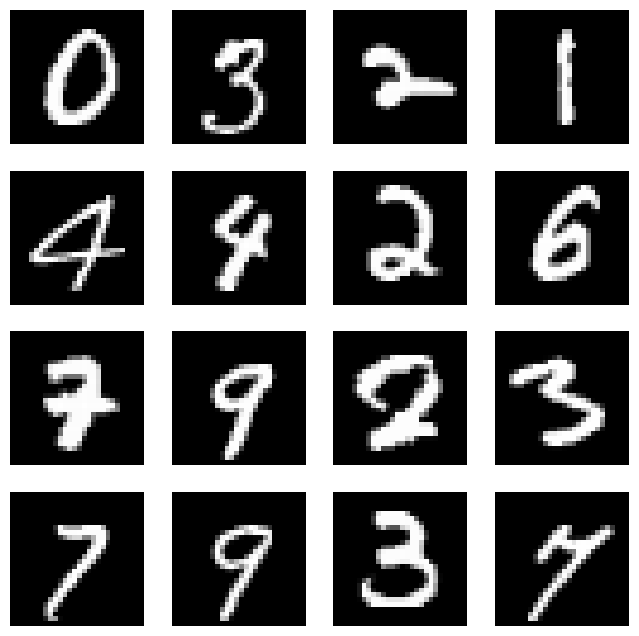

In [17]:
number_of_train_images = len(X_train)
number_of_train_images_to_show = 16 # for example, but feel free to show more images
random_list_of_images_to_show = np.random.randint(0, number_of_train_images , number_of_train_images_to_show)

fig, axs = plt.subplots(4, 4, figsize=(8,8))
for i, ax in zip(random_list_of_images_to_show, axs.flatten()):
    ax.imshow(X_train[i], cmap='gray')
    ax.axis('off')
plt.show()

### 1.2 Image Preprocessing

Normalise the intensities:

In [18]:
X_train = X_train / 255.
X_test = X_test / 255.

In [21]:
X_train.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

We have 60,000 training images and 10,000 test images, each of size (28, 28)

But a Convolutional Neural Network models need to be fed with images whose last dimension is the number of channels `(NUMBER_OF_IMAGES, HEIGHT, WIDTH, CHANNELS)`

The images are grayscale images i.e. they only have one channel, this is why the shape the each image is (28,28) and not (28,28,1) as the last dimension is not useful in general  

But in this case, we need to add it explicitely

In [7]:
from tensorflow.keras.backend import expand_dims

In [22]:
X_train = expand_dims(X_train, axis=-1)
X_test = expand_dims(X_test, axis=-1)

print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


### 1.4 Target/Class encoding

We have a multiclass classification task. We need to one-hot-encode the categories:

To do that we use the function **`to_categorical`** to transform your labels. 

In [24]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

In [25]:
# Quick check that you correctly used to_categorical
assert(y_train_cat.shape == (60000,10))
assert(y_test_cat.shape == (10000,10))

The data is now ready to be used. ✅

## 3 The Convolutional Neural Network

### 3.1 Architecture and compilation of a CNN

In [37]:
from tensorflow.keras import layers
from tensorflow.keras import models

def initialize_model():
    model = models.Sequential(name="MNIST_CNN")

    model.add(layers.Input(shape=(28, 28, 1), name='Input_Layer'))

    ### First Convolution & MaxPooling
    model.add(layers.Conv2D(8, (4,4), activation='relu', padding='same', name='L1_Conv'))
    model.add(layers.MaxPool2D(pool_size=(2,2)))
    
    ### Second Convolution & MaxPooling
    model.add(layers.Conv2D(16, (3,3), activation='relu', padding='same', name='L2_Conv'))
    model.add(layers.MaxPool2D(pool_size=(2,2)))

    ### Flattening
    model.add(layers.Flatten())

    ### One Fully Connected layer - "Fully Connected" is equivalent to saying "Dense"
    model.add(layers.Dense(10, activation='relu', name='L3_FC'))

    ### Last layer - Classification Layer with 10 outputs corresponding to 10 digits
    model.add(layers.Dense(10, activation='softmax', name='L4_Output'))
    
    ### Model compilation
    model.compile(loss='categorical_crossentropy',
                  optimizer='adam', 
                  metrics=['accuracy'])
    
    return model

In [38]:
model = initialize_model()
model.summary()

Model: "MNIST_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1_Conv (Conv2D)                │ (None, 28, 28, 8)      │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 14, 14, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2_Conv (Conv2D)                │ (None, 14, 14, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3_FC (Dense)                   │ (None, 10)             │         7,850 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L4_Output (Dense)               │ (None, 10)             │           110 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,264 (36.19 KB)

 Trainable params: 9,264 (36.19 KB)

 Non-trainable params: 0 (0.00 B)

### (2.2) Training a CNN

In [39]:
from tensorflow.keras.callbacks import EarlyStopping

model = initialize_model()
es = EarlyStopping(patience = 3)
history = model.fit(X_train, 
                    y_train_cat,
                    validation_split = 0.3,
                    batch_size = 32,
                    epochs = 25,
                    callbacks = [es],
                    verbose = 1)


Epoch 1/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7527 - loss: 0.7599 - val_accuracy: 0.9572 - val_loss: 0.1464
Epoch 2/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9636 - loss: 0.1262 - val_accuracy: 0.9722 - val_loss: 0.0935
Epoch 3/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9738 - loss: 0.0852 - val_accuracy: 0.9752 - val_loss: 0.0796
Epoch 4/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9787 - loss: 0.0669 - val_accuracy: 0.9749 - val_loss: 0.0845
Epoch 5/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9827 - loss: 0.0571 - val_accuracy: 0.9782 - val_loss: 0.0708
Epoch 6/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9851 - loss: 0.0484 - val_accuracy: 0.9815 - val_loss: 0.0640
Epoch 7/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9857 - loss: 0.0459 - val_accuracy: 0.9819 - val_loss: 0.0643
Epoch 8/25
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9872 - loss: 0.0400 - 

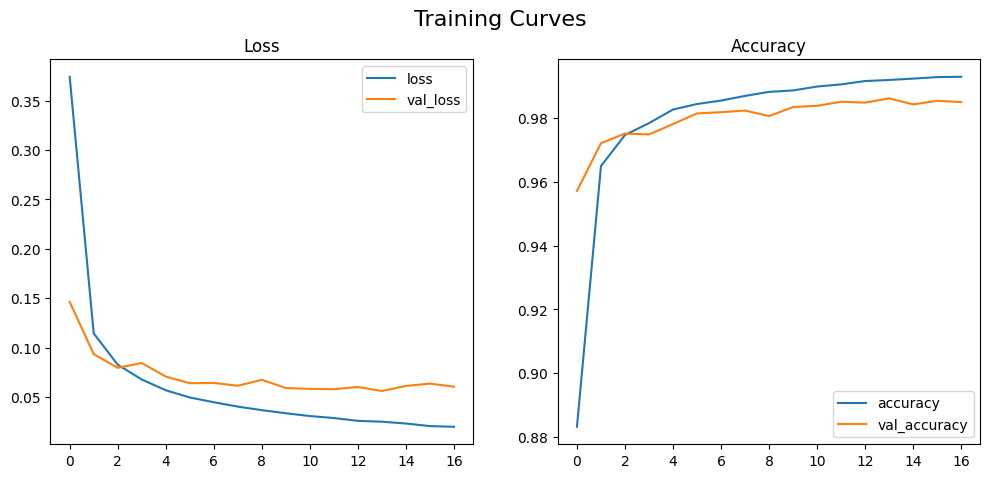

In [47]:
pd.DataFrame(history.history).columns
fig, (ax1,ax2) = plt.subplots(1, 2, figsize=(12,5))
pd.DataFrame(history.history).loc[:,['loss', 'val_loss']].plot(ax=ax1, title='Loss');  
pd.DataFrame(history.history).loc[:, ['accuracy', 'val_accuracy']].plot(ax=ax2, title='Accuracy');
fig.suptitle('Training Curves', fontsize=16);

### (2.3) Evaluating its performance

In [48]:
res = model.evaluate(X_test, y_test_cat, verbose = 1 )
print(f'The accuracy on the test set is of {res[1]*100:.2f} %')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9836 - loss: 0.0519
The accuracy on the test set is of 98.62 %


## Now let's test the model with your own image

### Load the image and preprocess it

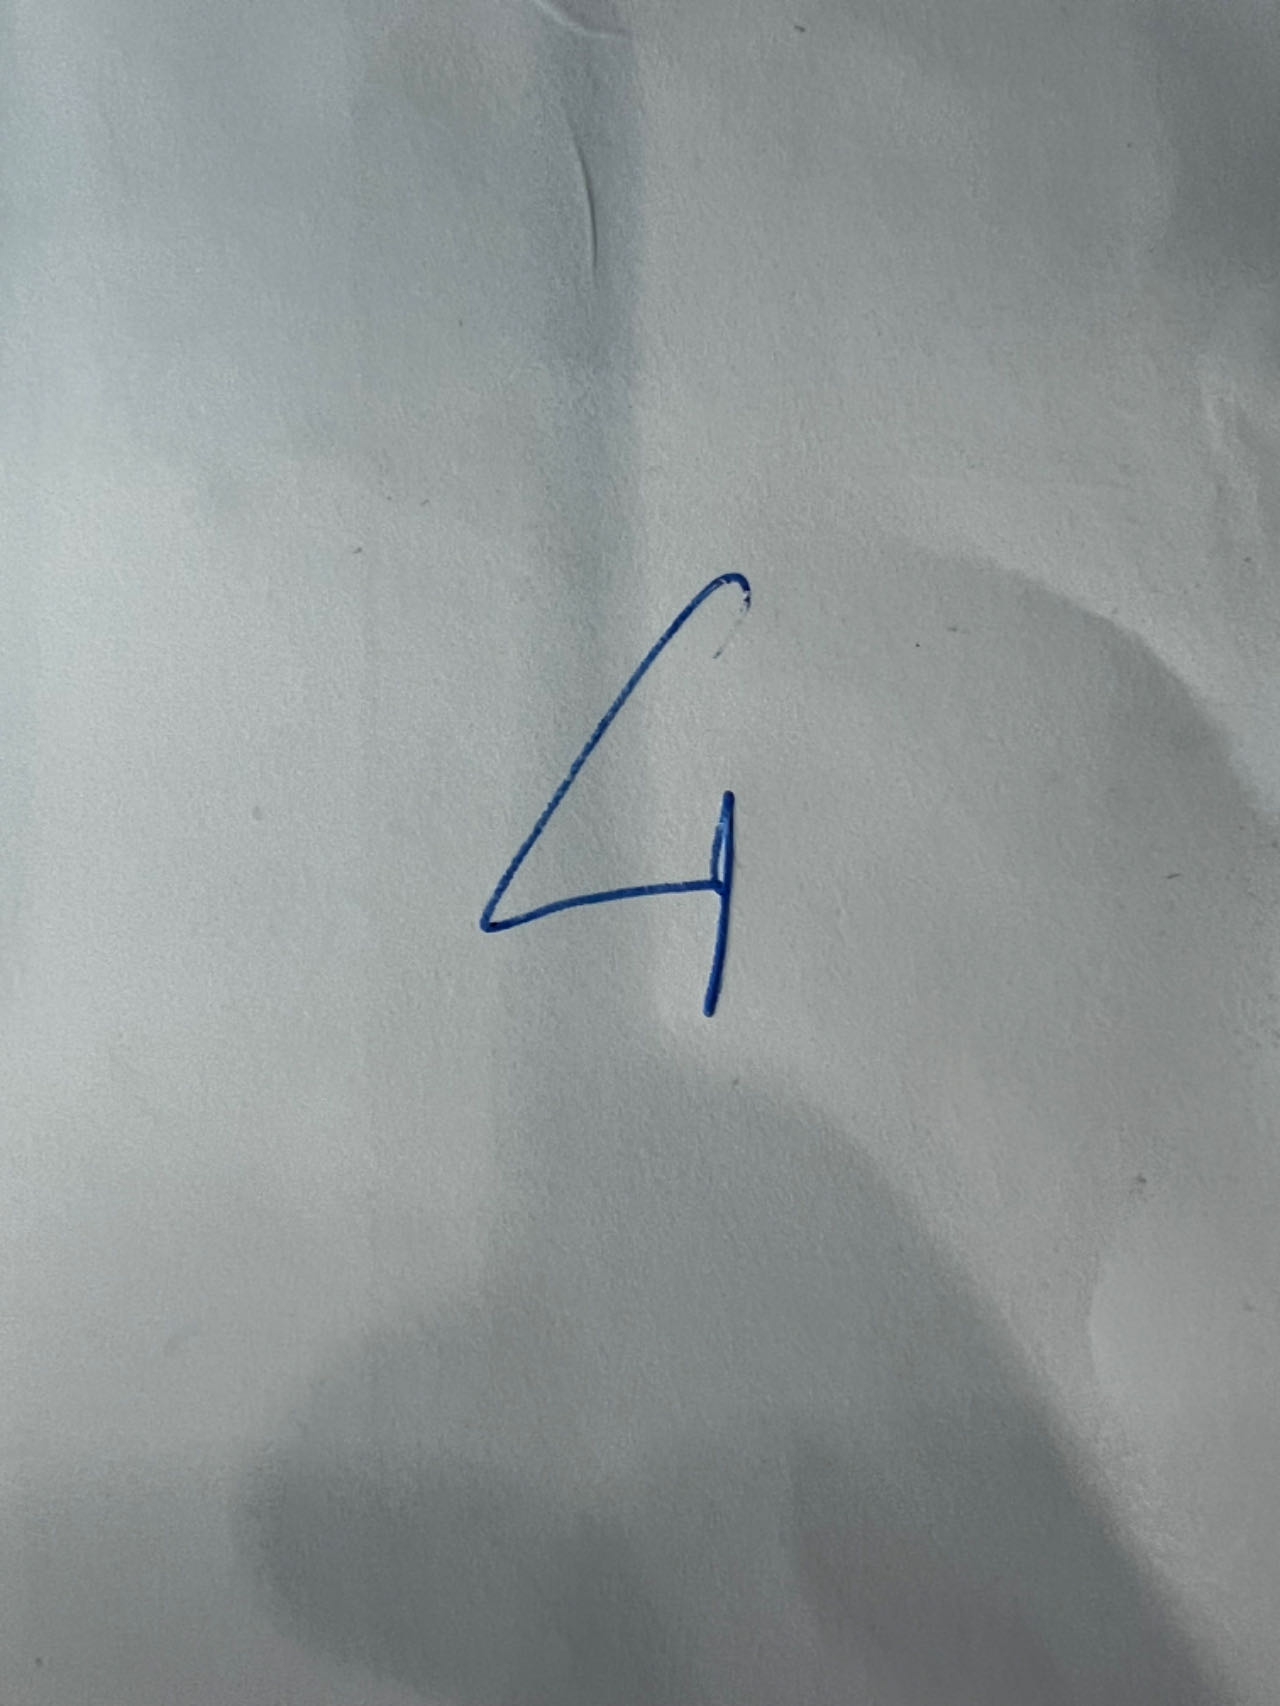

In [50]:
from PIL import Image

im = Image.open("cv_2_mnist-tf-test-digit-1.png")
im

In [51]:
width, height = im.size
box = (0, height/2-width/2, width, height/2+width/2) # left upper right lower
region = im.crop(box)
w,h = region.size
print(w,h)
# region

1280 1280


In [52]:
width, height = region.size
box = (0+width*0.25, height*0.25, width*0.75, height*0.75) # left upper right lower
region2 = region.crop(box)
w,h = region2.size
print(w,h)
# region2


640 640


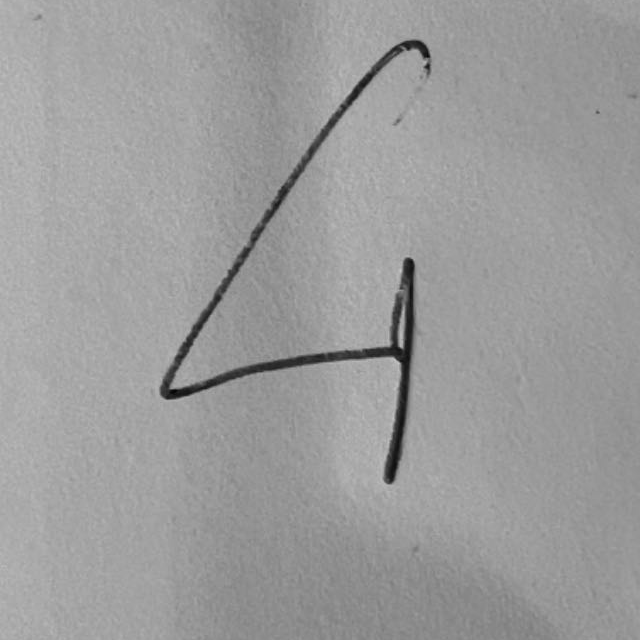

In [53]:
region2bw = region2.convert("L")
region2bw

In [54]:
region2bwenhanced = region2bw.point(lambda i: 0 if i > 120 else 255)
# region2bwenhanced

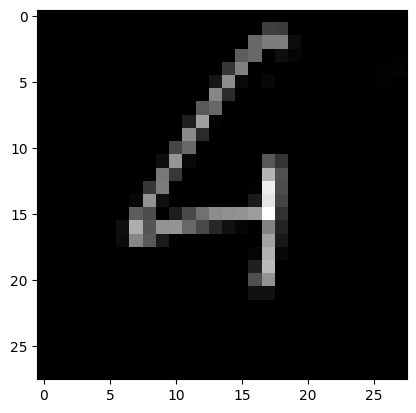

In [55]:
im2arr = np.array(region2bwenhanced.resize((28,28)))
plt.imshow(im2arr, cmap='gray');

Make the list of images with one image

In [56]:
im2arr = [im2arr]

In [57]:
X_me = expand_dims(im2arr, axis=-1)

Confirm we have the correct shape

In [61]:
X_me.shape

TensorShape([1, 28, 28, 1])

Predictions: 10 values between 0 and 1, whose sum is also 1

In [64]:
probs = model.predict(X_me)
probs, probs.sum()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


(array([[0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]], dtype=float32), 1.0)

Extract the label with the highest value

In [65]:
np.argmax(probs)

4